In [2]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


df = pd.read_excel("../data/raw/Base_de_datos.xlsx")

df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvi

tipo_credito                        0
fecha_prestamo                      0
capital_prestado                    0
plazo_meses                         0
edad_cliente                        0
tipo_laboral                        0
salario_cliente                     0
total_otros_prestamos               0
cuota_pactada                       0
puntaje                             0
puntaje_datacredito                 6
cant_creditosvigentes               0
huella_consulta                     0
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
creditos_sectorFinanciero           0
creditos_sectorCooperativo          0
creditos_sectorReal                 0
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
Pago_atiempo                        0
dtype: int64

In [20]:
# Variables categóricas
df["tipo_laboral"] = df["tipo_laboral"].astype("category")

df["tendencia_ingresos"] = df["tendencia_ingresos"].astype("category")

df["tipo_credito"] = df["tipo_credito"].astype("category")

# Variable objetivo binaria
df["Pago_atiempo"] = df["Pago_atiempo"].astype("bool")

# Verificación final
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  category      
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  category      
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvi

Se realizó la conversión de variables al tipo de dato más apropiado según su naturaleza. Las variables categóricas fueron convertidas a category, la variable objetivo Pago_atiempo a bool y la fecha del préstamo a datetime. Esto mejora la consistencia del dataset y optimiza el análisis posterior.

In [ ]:
#Conversión fecha
df["fecha_prestamo"] = pd.to_datetime(
    df["fecha_prestamo"],
    errors="coerce"
)

In [19]:
#Unificacion de nulos 
df = df.replace(
    ["NA", "N/A", "null", "-", ""],
    pd.NA
)

Se realizó la conversión de la columna fecha_prestamo al tipo datetime para facilitar futuros análisis temporales.

También se unificaron posibles representaciones de valores nulos (NA, N/A, null, "-", cadenas vacías) utilizando pd.NA para mantener consistencia en el dataset.

In [23]:
df["edad_cliente"].describe()

count    10613.000000
mean        42.845661
std         11.947307
min         19.000000
25%         33.000000
50%         42.000000
75%         52.000000
max         69.000000
Name: edad_cliente, dtype: float64

In [24]:
df = df[
    (df["edad_cliente"] >= 18) &
    (df["edad_cliente"] <= 100)
]

In [25]:
df[df["salario_cliente"] < 0]

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo


In [26]:
df[df["capital_prestado"] < 0]

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo


Se identificaron valores extremos en variables financieras como salario_cliente y capital_prestado. Sin embargo, no fueron eliminados en esta etapa debido a que podrían representar casos válidos dentro del negocio.

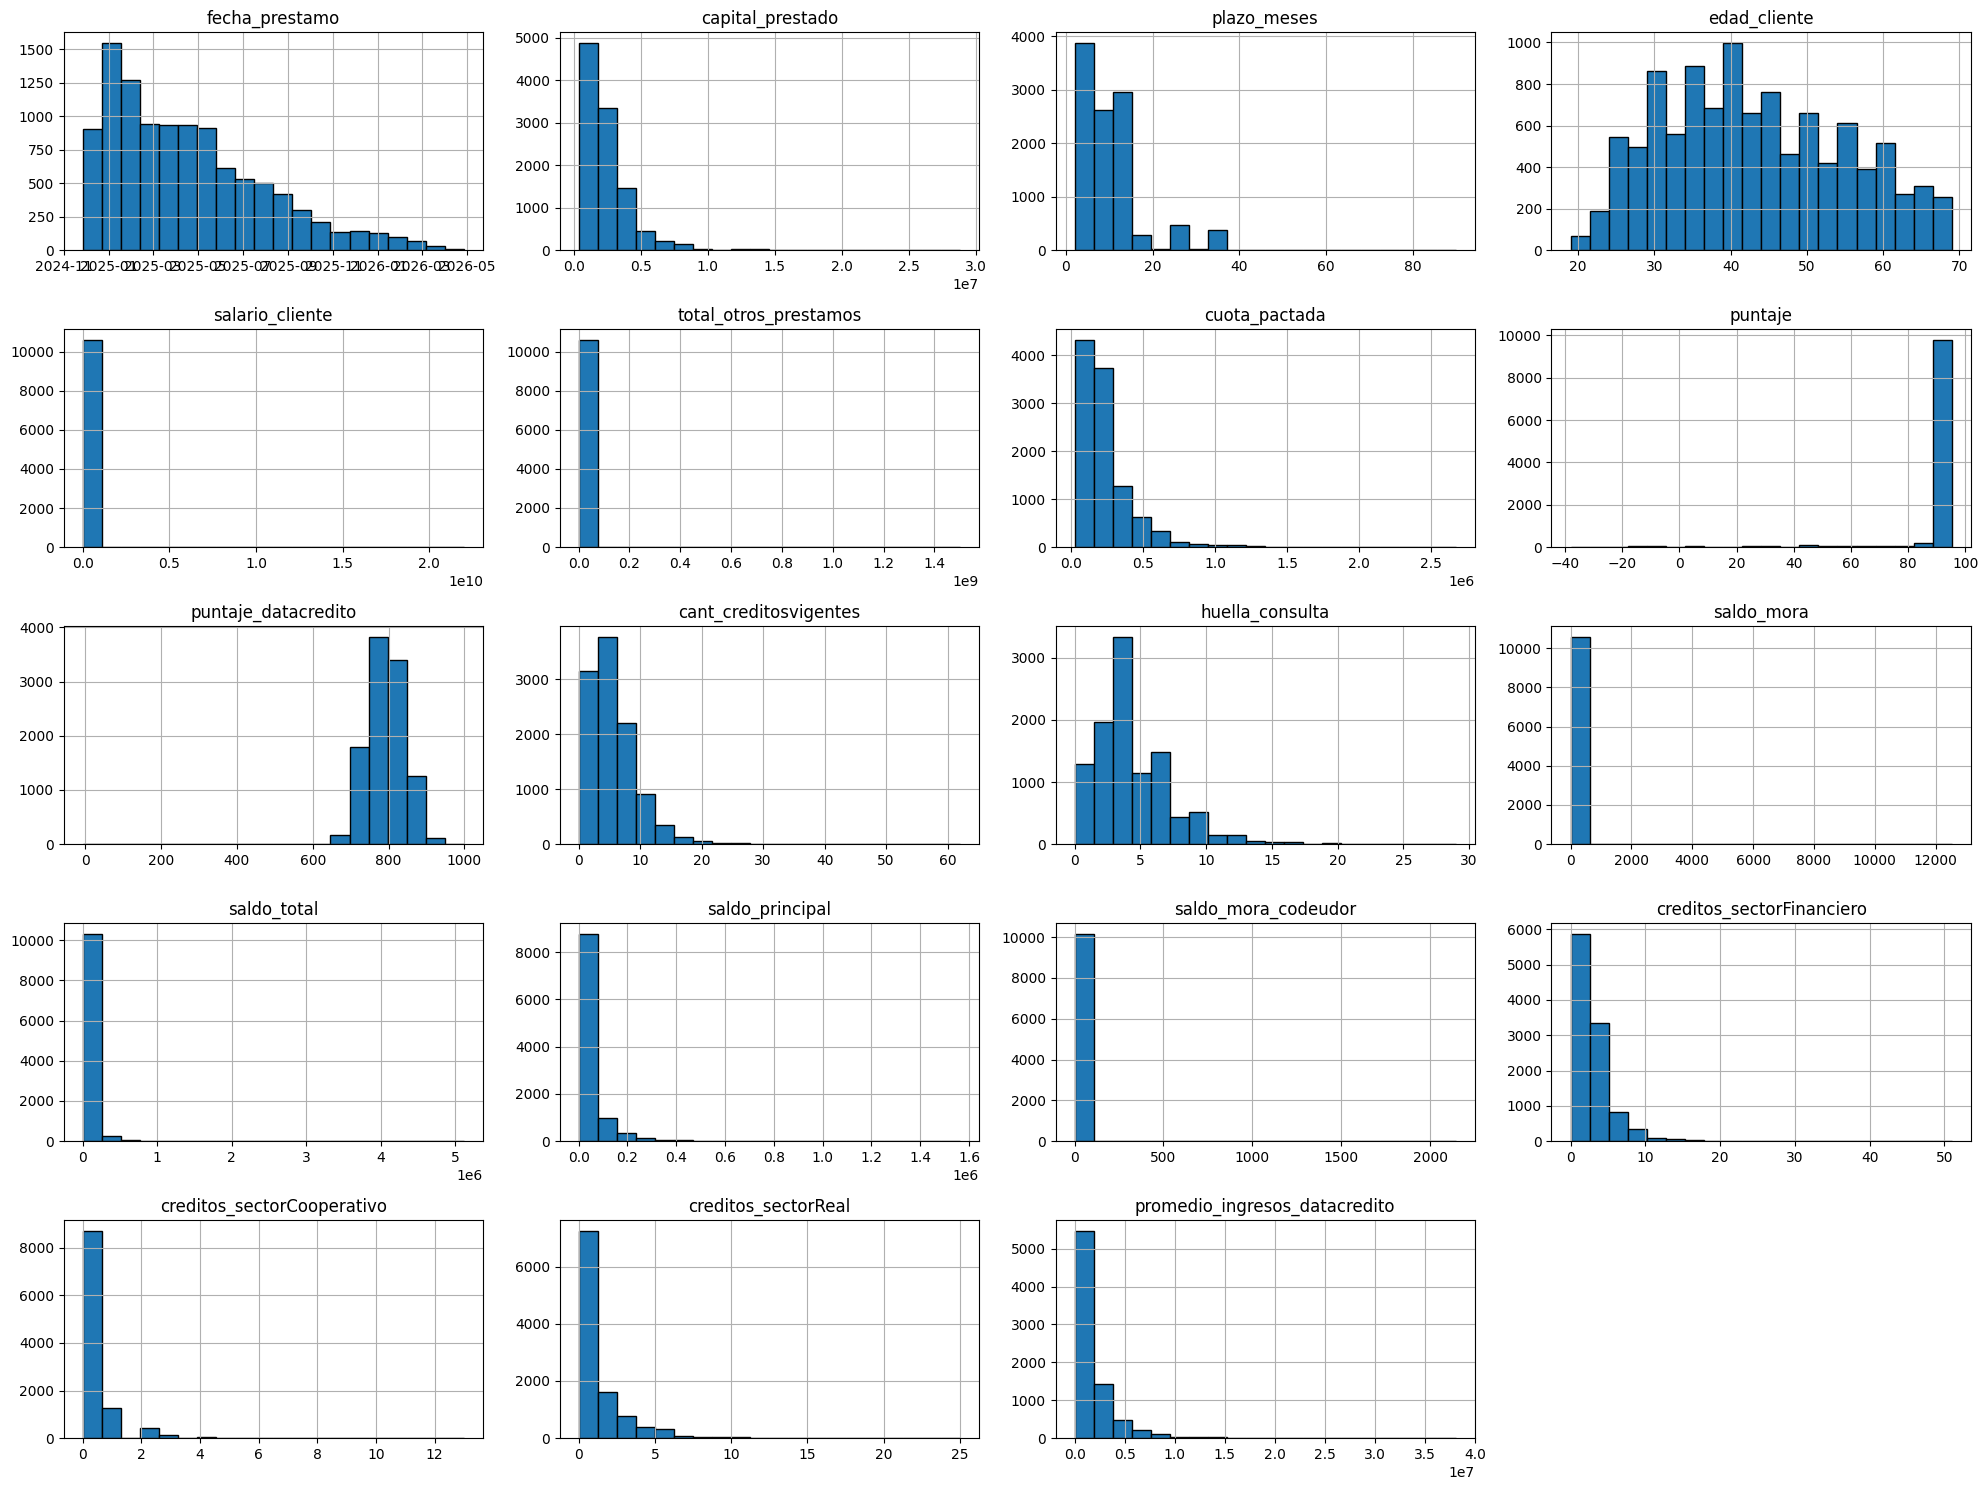

In [27]:
df.hist(
    figsize=(20,15),
    bins=20,
    edgecolor="black"
)

plt.tight_layout()

plt.show()

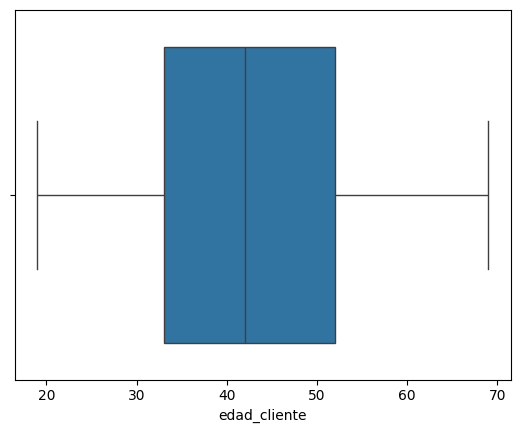

In [28]:
#Boxplot de edad de los clientes 

sns.boxplot(x=df["edad_cliente"])
plt.show()

In [29]:
#Cantidad de empleados e independientes

df["tipo_laboral"].value_counts()


tipo_laboral
Empleado         6604
Independiente    4009
Name: count, dtype: int64

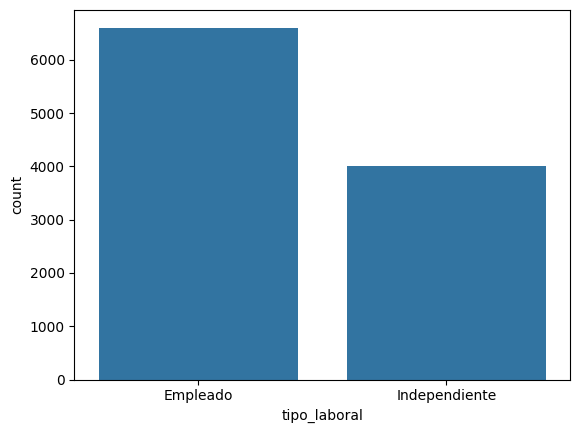

In [30]:
#Gráfico de cantidad de empleados e independientes

sns.countplot(x=df["tipo_laboral"])
plt.show()

<Axes: xlabel='capital_prestado', ylabel='salario_cliente'>

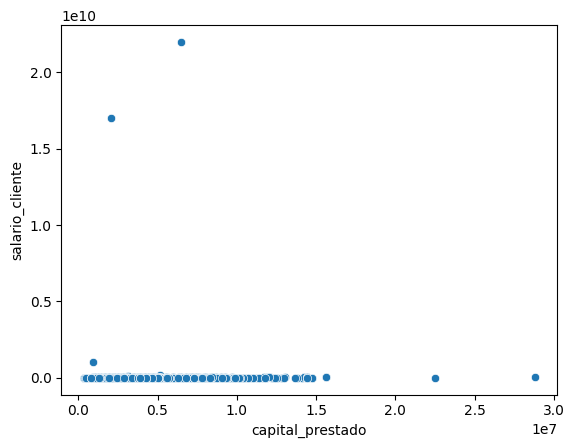

In [31]:
#No existe una relacion clara entre salario y capital prestado

sns.scatterplot(x="capital_prestado", y="salario_cliente", data=df)

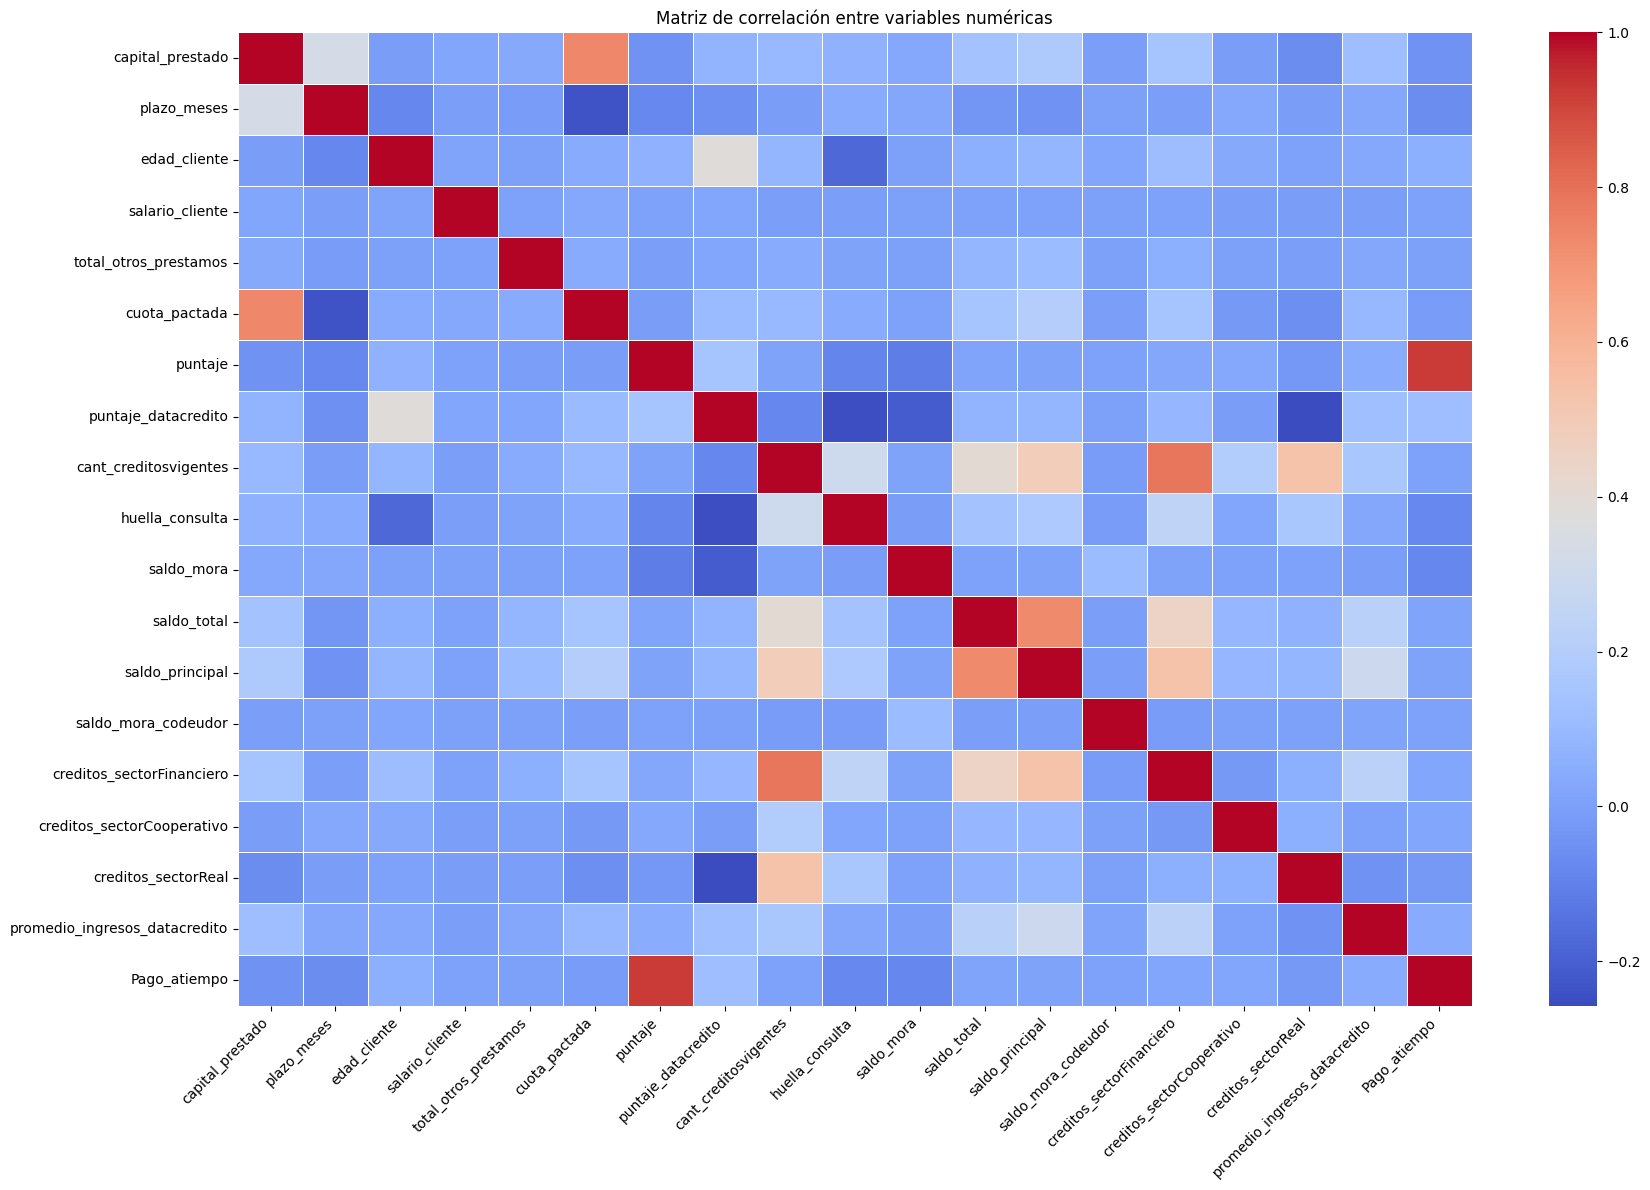

In [32]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Matriz de correlación entre variables numéricas")

plt.tight_layout()
plt.show()

a matriz de correlación permitió identificar relaciones entre variables numéricas. Se destacan correlaciones positivas entre capital_prestado y cuota_pactada, así como entre saldo_total y saldo_principal. Además, se observa una fuerte relación positiva entre puntaje y Pago_atiempo, indicando que un mejor score crediticio se asocia con mayor cumplimiento de pago. En general, la mayoría de las variables presentan correlaciones bajas o moderadas.

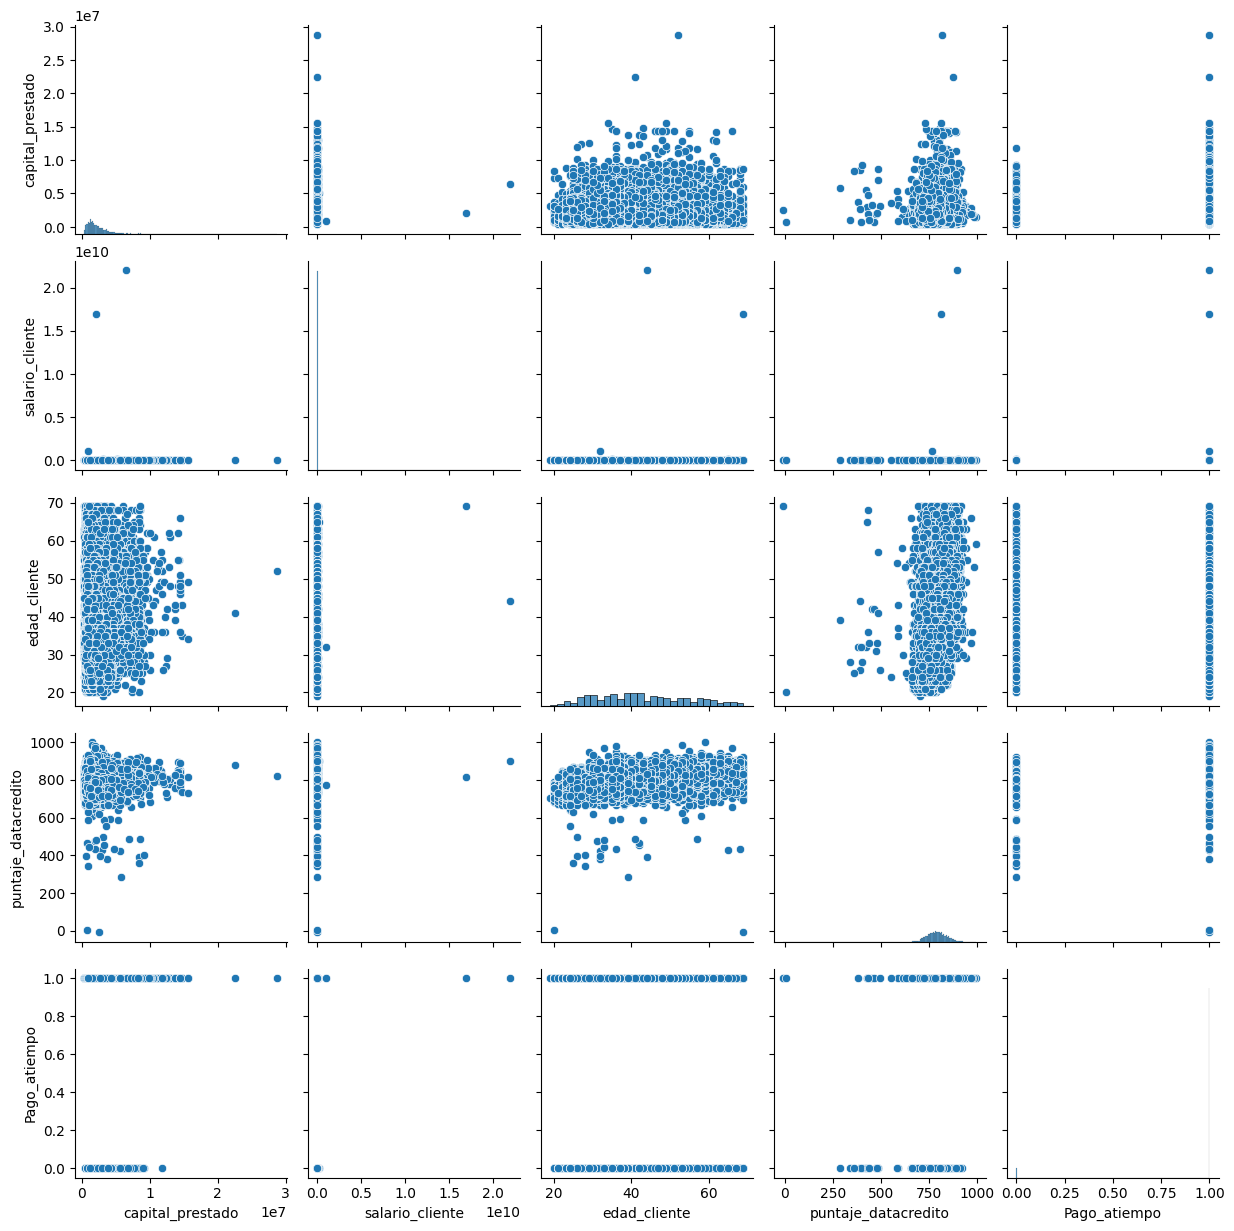

In [33]:
columnas = [
    "capital_prestado",
    "salario_cliente",
    "edad_cliente",
    "puntaje_datacredito",
    "Pago_atiempo"
]

sns.pairplot(df[columnas])

plt.show()